# Example: Building the Cobb-Douglas Allocator

In this example, we pick up the portfolio you built in Session 1 and show how to drive it adaptively. We load the user-selected universe and calibrated SIM parameters from the Session 1 min-var notebook, generate a single hybrid-SIM forward path via [`generate_hybrid_scenario(...)`](../../code/docs/build/session1.html), compute the EMA crossover sentiment signal, and solve the **Cobb-Douglas utility maximization** problem at each trading day. We then compare Cobb-Douglas against two alternatives: CES and log-linear utility. Let's dive in!

> **By the end of this example, you will be able to:**
> * __Generate synthetic prices and sentiment:__ Load the calibrated SIM parameters from Session 1 and generate a single forward path via the hybrid-SIM surrogate, then compute the $\lambda_t$ sentiment signal from EMA crossovers. These inputs feed directly into the preference weight calculation.
> * __Solve the Cobb-Douglas allocation:__ Solve the budget-constrained Cobb-Douglas allocation problem analytically to obtain optimal share counts. The closed-form solution routes capital toward preferred assets while maintaining a minimum floor for non-preferred ones.
> * __Compare utility function behavior:__ Compare allocation behavior across Cobb-Douglas, CES, and log-linear utility functions. The choice of utility function controls portfolio concentration for the same set of preference weights.


## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

[ Info: Precompiling eCornellAIFinance [a1b2c3d4-e5f6-7890-abcd-ef1234567890] (cache misses: include_dependency fsize change (6), mismatched flags (10))



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


### Implementation
We define three helper functions used later to measure portfolio concentration across utility functions and to build buy-and-hold baseline wealth series.

> __`top_asset_fraction(shares_mat; ...)`__
>
> Computes the fraction of total portfolio value held in the largest single position at each trading day. Takes a `T×N` share-count matrix `shares_mat` and returns a `Vector{Float64}` of length `T_trade` with values in `[1/N, 1]`.

> __`concentration_stats(shares_mat; ...)`__
>
> Computes the mean and standard deviation of the Herfindahl-Hirschman Index (HHI) across trading days. Takes a `T×N` share-count matrix `shares_mat` and returns a `NamedTuple` with fields `mean::Float64` and `std::Float64`.

> __`buyhold_series(weights, price_matrix, offset, B₀)`__
>
> Computes a buy-and-hold wealth trajectory on a single price path. Buys shares at day `offset+1` using the supplied `weights` and budget `B₀`, then marks to market through the end of the path. Returns a `Vector{Float64}` of length `T - offset`. Used downstream to snapshot the baseline wealth series we hand off to the next notebook.


In [2]:
"""
    top_asset_fraction(shares_mat::Matrix{Float64}) -> Vector{Float64}

Compute the fraction of total portfolio value held in the largest single position at each trading day.
Uses global variables `offset`, `n_trading_days`, `price_matrix`, and `my_tickers`.

### Arguments
- `shares_mat::Matrix{Float64}`: A `T_trade × N` matrix of share counts, where each row is a trading day and each column is an asset.

### Returns
- `Vector{Float64}` of length `T_trade` with values in `[1/N, 1]`.
"""
function top_asset_fraction(shares_mat::Matrix{Float64})::Vector{Float64}

    # --- Step 1: Setup ---
    N = length(my_tickers);
    T_trade = n_trading_days;
    fracs = zeros(T_trade);

    # --- Step 2: Compute top-asset fraction for each trading day ---
    for d in 1:T_trade
        actual_day = offset + d;
        # dollar value of each asset position = shares * price
        values = [shares_mat[d, k] * price_matrix[actual_day, k + 1] for k in 1:N];
        fracs[d] = maximum(values) / sum(values);  # fraction in the largest position
    end

    # --- Step 3: Return ---
    return fracs;
end

"""
    concentration_stats(shares_mat::Matrix{Float64}) -> NamedTuple{(:mean, :std), Tuple{Float64, Float64}}

Compute the mean and standard deviation of the Herfindahl-Hirschman Index (HHI) across trading days.
HHI = sum of squared portfolio weight fractions; ranges from `1/N` (equal weight) to `1.0` (all in one asset).
Uses global variables `offset`, `n_trading_days`, `price_matrix`, and `my_tickers`.

### Arguments
- `shares_mat::Matrix{Float64}`: A `T_trade × N` matrix of share counts, where each row is a trading day and each column is an asset.

### Returns
- A `NamedTuple` with fields `mean::Float64` and `std::Float64`.
"""
function concentration_stats(shares_mat::Matrix{Float64})

    # --- Step 1: Setup ---
    N = length(my_tickers);
    T_trade = n_trading_days;
    hhi_vals = zeros(T_trade);

    # --- Step 2: Compute HHI for each trading day ---
    for d in 1:T_trade
        actual_day = offset + d;
        # dollar value of each position
        values = [shares_mat[d, k] * price_matrix[actual_day, k + 1] for k in 1:N];
        weights = values ./ sum(values);  # normalize to portfolio weight fractions
        hhi_vals[d] = sum(weights .^ 2);  # HHI = sum of squared weights
    end

    # --- Step 3: Return ---
    return (mean=round(mean(hhi_vals), digits=4), std=round(std(hhi_vals), digits=4));
end

"""
    buyhold_series(weights::Vector{Float64}, price_matrix::Matrix{Float64}, offset::Int, B₀::Float64) -> Vector{Float64}

Compute a buy-and-hold wealth series on a single price path. Shares are purchased at day `offset+1`
using the supplied portfolio weights (summing to one) and an initial budget `B₀`, then held through
the end of the price matrix.

### Arguments
- `weights::Vector{Float64}`: Portfolio weights of length `N`, summing to one.
- `price_matrix::Matrix{Float64}`: `T × (N+1)` price matrix; column 1 is the day index, columns 2:N+1 are ticker prices.
- `offset::Int`: Warmup length in days; the buy-in happens at `offset+1`.
- `B₀::Float64`: Initial budget in dollars.

### Returns
- `Vector{Float64}` of length `T - offset` with the wealth trajectory from the buy-in day forward.
"""
function buyhold_series(weights::Vector{Float64}, price_matrix::Matrix{Float64},
    offset::Int, B₀::Float64)::Vector{Float64}

    # --- Step 1: Setup ---
    T = size(price_matrix, 1);
    N = length(weights);
    t_start = offset + 1;

    # --- Step 2: Shares purchased at buy-in day using weights × B₀ ---
    p_start = [price_matrix[t_start, k + 1] for k in 1:N];
    shares  = B₀ .* weights ./ p_start;

    # --- Step 3: Mark-to-market wealth from buy-in day to end of path ---
    wealth = zeros(T - offset);
    for (i, t) in enumerate(t_start:T)
        wealth[i] = sum(shares[k] * price_matrix[t, k + 1] for k in 1:N);
    end
    return wealth;
end;


The `let...end` block below loads the Session 1 artifacts, defines the rebalancing-engine hyperparameters, and constructs the allocator's sim-parameter dictionary. The globals it produces are: `my_tickers::Vector{String}`, `sim_estimates::Vector{MySIMParameterEstimate}`, `σ_m::Float64`, `g_f::Float64`, `minvar_weights::Vector{Float64}`, `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`, and the scalar hyperparameters `B₀`, `Δt`, `L_short`, `L_long`, `L_growth`, `GAIN`, `offset`, `n_trading_days`, `T_total`, `ε`, `N`.

In [3]:
let
    # --- Step 1: Load S1 artifacts (tickers the user picked in Session 1) ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    global my_tickers     = minvar["my_tickers"]::Vector{String};
    global sim_estimates  = minvar["sim_estimates"];
    global σ_m            = Float64(minvar["sigma_market"]);
    global g_f            = haskey(minvar, "g_f") ? Float64(minvar["g_f"]) : (haskey(minvar, "r_f") ? Float64(minvar["r_f"]) : 0.045);
    global minvar_weights = Float64.(minvar["allocation_weights"]);

    # --- Step 2: Rebalancing-engine hyperparameters and time grid ---
    global B₀             = 10_000.0;
    global Δt             = 1.0 / 252.0;
    global L_short        = 21;                       # fast EMA window (~1 month)
    global L_long         = 63;                       # slow EMA window (~1 quarter)
    global L_growth       = 10;                       # market-growth smoothing window
    global GAIN           = 10.0;                     # λ sensitivity on the EMA crossover
    global offset         = L_short + L_long;         # 84-day warmup
    global n_trading_days = 252;                      # one year of active trading
    global T_total        = offset + n_trading_days;  # 336
    global ε              = 0.1;                      # ε floor for non-preferred assets
    global N              = length(my_tickers);

    # --- Step 3: Adapter — build the allocator's sim_params::Dict from sim_estimates ---
    global sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    println("S1 universe loaded: $(N) tickers = $(my_tickers)")
    println("  σ_m (growth rate, 1/yr): $(round(σ_m, digits=4))")
    println("  g_f (continuous, %/yr):  $(round(g_f*100, digits=2))")
    println("Time grid: warmup = $(offset) days, trading = $(n_trading_days) days, total = $(T_total) days")
end

S1 universe loaded: 10 tickers = ["AAPL", "MSFT", "NVDA", "JNJ", "JPM", "PG", "XOM", "BA", "GS", "AMD"]


  σ_m (growth rate, 1/yr): 3.1234
  g_f (continuous, %/yr):  4.5
Time grid: warmup = 84 days, trading = 252 days, total = 336 days


___
## Task 1: Generate Synthetic Market Data and Compute Sentiment Signal
We generate one forward market path using the same hybrid-SIM surrogate that Session 1 used for stress testing, then compute per-ticker price paths consistent with the Session 1 calibration. From the market path we build the short and long EMAs and derive the crossover sentiment signal $\lambda_t$ that will feed into the preference weights.

> __What should you see?__
>
> The market index follows a mildly random trajectory from the Jump-HMM surrogate. The short EMA hugs price; the long EMA smooths it. When the short EMA crosses below the long EMA, $\lambda > 0$ (bearish); when it crosses above, $\lambda < 0$ (bullish). Per-ticker paths are correlated with the market through their $\beta_i$ values and carry the ticker-specific $\alpha_i$ drift and $\sigma_{\epsilon,i}$ idiosyncratic noise from the Session 1 calibration.

The `let...end` block below loads the surrogate models and starting prices, calls [the `generate_hybrid_scenario(...)` function](../../code/docs/build/session1.html) with `n_paths=1, n_steps=T_total, seed=2026`, and computes EMAs, $\lambda$, and the smoothed market growth rate. The globals it produces are `market_prices::Vector{Float64}`, `price_matrix::Matrix{Float64}`, `ema_short::Vector{Float64}`, `ema_long::Vector{Float64}`, `lambda_series::Vector{Float64}`, and `gm_ema::Vector{Float64}`.

In [4]:
let
    # --- Step 1: Load surrogates and calibration (source of truth for paths) ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));

    # --- Step 2: Match S1 start-price snapshot for my_tickers ---
    snap = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);

    # --- Step 3: Generate one hybrid-SIM path over the full T_total horizon ---
    # n_paths = 1 because this notebook illustrates the allocator on a single,
    # reproducible trajectory; distributional analysis lives downstream.
    scenario = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths      = 1,
        n_steps      = T_total,
        Δt           = Δt,
        start_prices = start_prices,
        label        = "S2-CobbDouglas-1p",
        seed         = 2026);

    # --- Step 4: Extract the single-path market and price series ---
    global market_prices = scenario.market_paths[1, :];

    # Build the (T × N+1) price matrix: column 1 = day index, columns 2:N+1 = ticker prices
    global price_matrix = zeros(T_total, N + 1);
    price_matrix[:, 1] = 1:T_total;
    for k in 1:N
        price_matrix[:, k + 1] = scenario.price_paths[1, :, k];
    end

    # --- Step 5: EMAs and the λ sentiment signal on the market path ---
    global ema_short    = compute_ema(market_prices; window = L_short);
    global ema_long     = compute_ema(market_prices; window = L_long);
    global lambda_series = compute_lambda(ema_short, ema_long; G = GAIN);
    lambda_series[1:offset] .= 0.0;    # zero warmup period before any EMA signal is usable

    # --- Step 6: Market growth rate (CCGR) and its smoothed version ---
    gm_raw     = compute_market_growth(market_prices; Δt = Δt);
    global gm_ema = compute_ema(gm_raw; window = L_growth);

    println("Generated $(T_total) days of synthetic market data via generate_hybrid_scenario")
    println("  market_prices[end] = $(round(market_prices[end], digits=2))")
    println("  λ range: [$(round(minimum(lambda_series), digits=3)), $(round(maximum(lambda_series), digits=3))]")
end

Generated 336 days of synthetic market data via generate_hybrid_scenario


  market_prices[end] = 88.72
  λ range: [-0.378, 0.486]


The code below plots the market price with both EMAs (top panel) and the lambda sentiment signal (bottom panel).

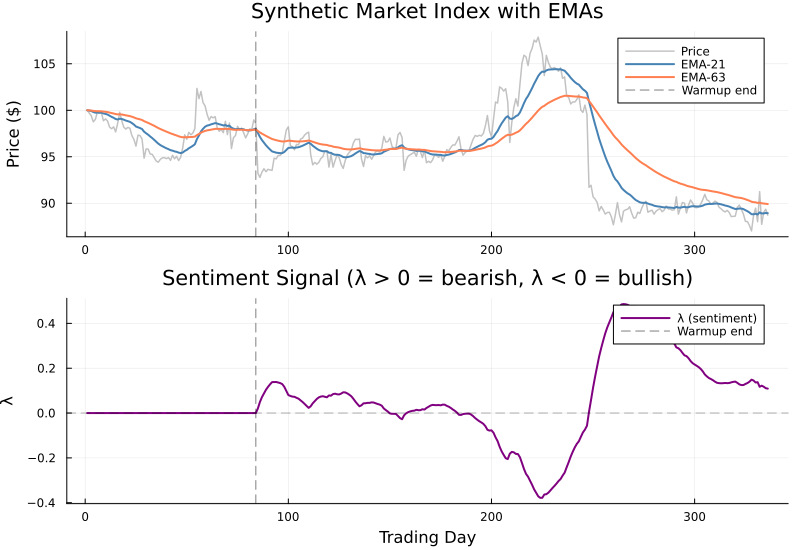

In [5]:
let
    T_total = length(market_prices);
    days = 1:T_total;

    # --- Top panel: market price with short and long EMAs ---
    p1 = plot(days, market_prices, label="Price", linewidth=1.5, color=:gray70, alpha=0.8)
    plot!(p1, days, ema_short, label="EMA-$(L_short)", linewidth=2, color=:steelblue)
    plot!(p1, days, ema_long, label="EMA-$(L_long)", linewidth=2, color=:coral)
    vline!(p1, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)
    ylabel!(p1, "Price (\$)")
    title!(p1, "Synthetic Market Index with EMAs")

    # --- Bottom panel: lambda sentiment signal ---
    p2 = plot(days, lambda_series, label="λ (sentiment)", linewidth=2, color=:purple)
    hline!(p2, [0.0], label="", linestyle=:dash, color=:black, alpha=0.3)  # zero reference line
    vline!(p2, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)
    xlabel!(p2, "Trading Day")
    ylabel!(p2, "λ")
    title!(p2, "Sentiment Signal (λ > 0 = bearish, λ < 0 = bullish)")

    # --- Combine into 2-row layout ---
    plot(p1, p2, layout=(2, 1), size=(800, 550), legend=:topright)
end

___
## Task 2: Cobb-Douglas Utility Allocation
Now we use the Cobb-Douglas utility function to allocate capital. At each time step, we compute preference weights $\gamma_i$ from SIM parameters and the current sentiment $\lambda_t$, then solve the analytical allocation:

$$n_i^{\star} = \frac{\gamma_i}{\sum_{j \in S^+} \gamma_j} \cdot \frac{B_{\text{adj}}}{P_i} \quad \text{(preferred)}, \qquad n_i^{\star} = \epsilon \quad \text{(non-preferred)}$$

To keep the notation aligned with the Session 2 lecture, we write the asset count as $N$, use the current price shorthand $P_i \equiv S_i(t)$, and interpret the one-step budget as $B \equiv W_{\mathcal{P}}(t)$. The optimal share counts $n_i^{\star}(t)$ map back to portfolio weights through $w_i(t) = n_i(t)S_i(t) / W_{\mathcal{P}}(t)$.

> __What should you see?__
>
> Preference weights shift over time as $\lambda$ changes. During bearish periods ($\lambda > 0$), high-$\beta$ assets should lose preference and the allocator should rotate toward lower-$\beta$ assets. During bullish periods ($\lambda < 0$), the ranking flips. Share allocations follow, with budget flowing toward whichever assets have the largest $\gamma_i$ on that day.

The `let...end` block below loops over trading days, calling [the `compute_preference_weights(...)` function](../../code/docs/build/session2.html) to obtain $\gamma_i$ values and then [the `allocate_cobb_douglas(...)` function](../../code/docs/build/session2.html) to solve for optimal shares. The globals it produces are `gamma_matrix::Matrix{Float64}`, `shares_matrix::Matrix{Float64}`, and `utility_series::Vector{Float64}`.

In [6]:
let
    T_trade = n_trading_days;

    # --- Step 1: Allocate storage for time series ---
    global gamma_matrix  = zeros(T_trade, N);    # preference weights γᵢ at each trading day
    global shares_matrix = zeros(T_trade, N);    # optimal share counts nᵢ* at each trading day
    global utility_series = zeros(T_trade);       # Cobb-Douglas utility value at each trading day

    # --- Step 2: Loop over each trading day ---
    for d in 1:T_trade
        actual_day = offset + d;                                         # full-series index (skip warmup)
        λ_t  = lambda_series[actual_day];                                # current sentiment signal
        gm_t = gm_ema[min(actual_day, length(gm_ema))];                  # smoothed market growth
        prices = [price_matrix[actual_day, k + 1] for k in 1:N];         # current prices for all N assets

        # --- Step 2a: Compute preference weights from SIM parameters + sentiment ---
        gamma = compute_preference_weights(sim_params, my_tickers, gm_t, λ_t);

        # --- Step 2b: Build and solve the Cobb-Douglas allocation problem ---
        problem = build(MyCobbDouglasChoiceProblem, (
            gamma = gamma, prices = prices, B = B₀, epsilon = ε
        ));
        (shares, cash) = allocate_cobb_douglas(problem);

        # --- Step 2c: Store results ---
        gamma_matrix[d, :]  = gamma;
        shares_matrix[d, :] = shares;
        utility_series[d]   = evaluate_cobb_douglas(shares, gamma);
    end

    println("Cobb-Douglas allocation computed for $(T_trade) trading days")
    println("Mean utility: $(round(mean(utility_series), digits=2))")
end

Cobb-Douglas allocation computed for 252 trading days


Mean utility: -2.298435359e8


> __What should you see?__
>
> The top panel shows how each asset's preference weight moves with sentiment. Low-$\beta$ assets stay relatively stable because they're less sensitive to changes in $\lambda$; high-$\beta$ assets should swing the most. The bottom panel shows the resulting share counts, where budget flows to whichever assets carry the largest $\gamma_i$ at each trading day.

The code below plots the preference weights $\gamma_i$ over time (top panel) and the corresponding share allocations (bottom panel).

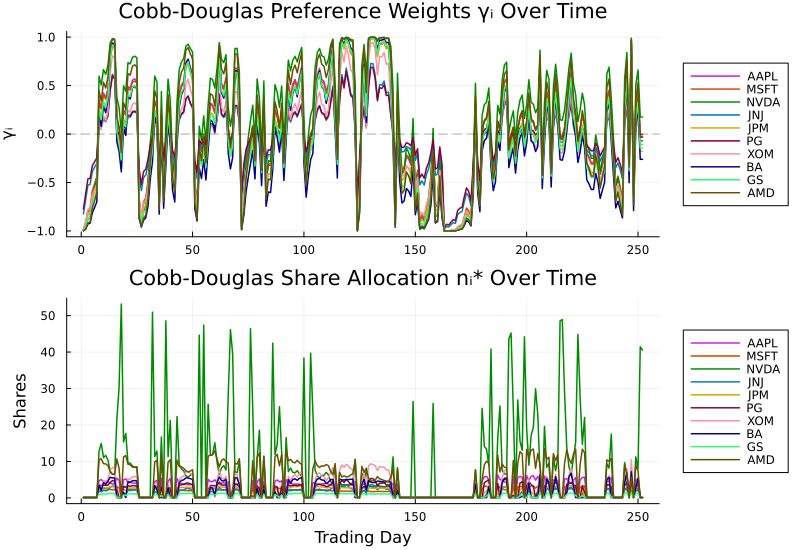

In [7]:
let
    days = 1:n_trading_days;
    palette = distinguishable_colors(N, [RGB(1,1,1), RGB(0,0,0)]; dropseed = true);

    # --- Top panel: preference weights γᵢ over time ---
    p1 = plot(size=(800, 250), title="Cobb-Douglas Preference Weights γᵢ Over Time",
        ylabel="γᵢ", legend=:outerright)
    for (k, ticker) in enumerate(my_tickers)
        plot!(p1, days, gamma_matrix[:, k], label=ticker, linewidth=1.5, color=palette[k])
    end
    hline!(p1, [0.0], label="", linestyle=:dash, color=:black, alpha=0.3)  # zero reference

    # --- Bottom panel: share allocations nᵢ* over time ---
    p2 = plot(size=(800, 250), title="Cobb-Douglas Share Allocation nᵢ* Over Time",
        xlabel="Trading Day", ylabel="Shares", legend=:outerright)
    for (k, ticker) in enumerate(my_tickers)
        plot!(p2, days, shares_matrix[:, k], label=ticker, linewidth=1.5, color=palette[k])
    end

    # --- Combine into 2-row layout ---
    plot(p1, p2, layout=(2, 1), size=(800, 550))
end

___
## Task 3: Compare Utility Functions (Cobb-Douglas vs. CES vs. Log-Linear)
We run the same scenario with three different utility functions and compare allocation behavior. The key question: **how does the choice of utility function affect portfolio concentration?**

CES with high $\sigma$ (elasticity of substitution) produces more concentrated portfolios, pushing more budget toward the single best asset. Cobb-Douglas is the middle ground. Log-linear produces the same allocation as Cobb-Douglas but different utility values.

> __What should you see?__
>
> Cobb-Douglas and log-linear allocations will be identical (the log transform preserves the optimum). CES with $\sigma = 3$ will be more concentrated, with the top asset getting a larger share of the budget. CES with $\sigma = 0.5$ will be more diversified.

The `let...end` block below computes allocations for all four utility variants using [the `allocate_cobb_douglas(...)` function](../../code/docs/build/session2.html), [the `allocate_ces(...)` function](../../code/docs/build/session2.html), and [the `allocate_log_linear(...)` function](../../code/docs/build/session2.html). The share matrices and utility vectors are stored as global variables for visualization.

In [8]:
let
    T_trade = n_trading_days;

    # --- Step 1: Allocate storage for each utility variant ---
    shares_cd       = zeros(T_trade, N);   # Cobb-Douglas shares
    shares_ces_high = zeros(T_trade, N);   # CES σ = 3.0 (concentrated)
    shares_ces_low  = zeros(T_trade, N);   # CES σ = 0.5 (diversified)
    shares_ll       = zeros(T_trade, N);   # Log-linear shares

    utility_cd       = zeros(T_trade);     # Cobb-Douglas utility values
    utility_ces_high = zeros(T_trade);     # CES high-σ utility values
    utility_ces_low  = zeros(T_trade);     # CES low-σ utility values
    utility_ll       = zeros(T_trade);     # Log-linear utility values

    # --- Step 2: Loop over trading days and compute all allocations ---
    for d in 1:T_trade
        actual_day = offset + d;  # skip warmup
        λ_t  = lambda_series[actual_day];
        gm_t = gm_ema[min(actual_day, length(gm_ema))];
        prices = [price_matrix[actual_day, k + 1] for k in 1:N];

        # preference weights are the same for all utility functions
        gamma = compute_preference_weights(sim_params, my_tickers, gm_t, λ_t);

        # --- Cobb-Douglas allocation ---
        cd_prob = build(MyCobbDouglasChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε));
        (s_cd, _) = allocate_cobb_douglas(cd_prob);
        shares_cd[d, :] = s_cd;
        utility_cd[d]   = evaluate_cobb_douglas(s_cd, gamma);

        # --- CES high σ (concentrated, σ = 3.0) ---
        ces_h = build(MyCESChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε, sigma=3.0));
        (s_ces_h, _) = allocate_ces(ces_h);
        shares_ces_high[d, :] = s_ces_h;
        utility_ces_high[d]   = evaluate_ces(s_ces_h, gamma; sigma=3.0);

        # --- CES low σ (diversified, σ = 0.5) ---
        ces_l = build(MyCESChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε, sigma=0.5));
        (s_ces_l, _) = allocate_ces(ces_l);
        shares_ces_low[d, :] = s_ces_l;
        utility_ces_low[d]   = evaluate_ces(s_ces_l, gamma; sigma=0.5);

        # --- Log-linear allocation ---
        ll_prob = build(MyLogLinearChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε));
        (s_ll, _) = allocate_log_linear(ll_prob);
        shares_ll[d, :] = s_ll;
        utility_ll[d]   = evaluate_log_linear(s_ll, gamma);
    end

    # --- Step 3: Store results as globals for downstream visualization ---
    global _shares_cd       = shares_cd;
    global _shares_ces_high = shares_ces_high;
    global _shares_ces_low  = shares_ces_low;
    global _shares_ll       = shares_ll;
    global _utility_cd       = utility_cd;
    global _utility_ces_high = utility_ces_high;
    global _utility_ces_low  = utility_ces_low;
    global _utility_ll       = utility_ll;

    println("Allocation computed for all 4 utility variants")
end

Allocation computed for all 4 utility variants


> __What should you see?__
>
> CES ($\sigma = 3$) should have the highest concentration, with more budget in the top asset. Cobb-Douglas and log-linear should be identical. CES ($\sigma = 0.5$) should be the most diversified.

The code below computes and plots the top-asset budget fraction over time for each utility function.

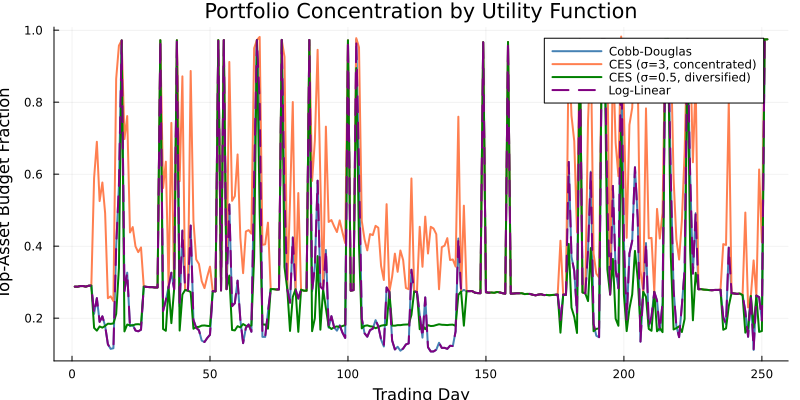

In [9]:
let
    T_trade = n_trading_days;

    # --- Step 1: Compute concentration metric for each utility variant ---
    f_cd = top_asset_fraction(_shares_cd);
    f_ces_h = top_asset_fraction(_shares_ces_high);
    f_ces_l = top_asset_fraction(_shares_ces_low);
    f_ll = top_asset_fraction(_shares_ll);

    # --- Step 2: Plot top-asset budget fraction over time ---
    days = 1:T_trade;
    plot(days, f_cd, label="Cobb-Douglas", linewidth=2, color=:steelblue)
    plot!(days, f_ces_h, label="CES (σ=3, concentrated)", linewidth=2, color=:coral)
    plot!(days, f_ces_l, label="CES (σ=0.5, diversified)", linewidth=2, color=:green)
    plot!(days, f_ll, label="Log-Linear", linewidth=2, color=:purple, linestyle=:dash)
    xlabel!("Trading Day")
    ylabel!("Top-Asset Budget Fraction")
    title!("Portfolio Concentration by Utility Function")
    plot!(size=(800, 400), legend=:topright)
end

The code below computes summary statistics (mean and standard deviation of the Herfindahl-Hirschman Index) for each utility function and displays them using [`pretty_table`](https://ronisbr.github.io/PrettyTables.jl/stable/).

In [10]:
let
    # --- Step 1: Compute HHI for each utility variant ---
    names = ["Cobb-Douglas", "CES (σ=3.0)", "CES (σ=0.5)", "Log-Linear"];
    mats  = [_shares_cd, _shares_ces_high, _shares_ces_low, _shares_ll];
    stats = [concentration_stats(m) for m ∈ mats];

    # --- Step 2: Build the summary DataFrame ---
    df = DataFrame(
        "Utility Function" => names,
        "Mean HHI"         => [s.mean for s ∈ stats],
        "Std HHI"          => [s.std  for s ∈ stats],
    );

    # --- Step 3: Display ---
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ------------------ ---------- ---------
  Utility Function   Mean HHI   Std HHI 
            String    Float64   Float64 
 ------------------ ---------- ---------
      Cobb-Douglas     0.2262    0.2292
       CES (σ=3.0)     0.3616    0.2726
       CES (σ=0.5)     0.2089    0.2202
        Log-Linear     0.2262    0.2292
 ------------------ ---------- ---------


___
### Hand-off to the next notebook
We now construct the rebalancing engine context and save the artifacts the next notebook will consume. The `let...end` block below builds a [`MyRebalancingContextModel`](../../code/docs/build/session2.html) from the single-path price data, precomputes three baseline wealth series (S1 min-var buy-and-hold, equal-weight buy-and-hold, and the deterministic risk-free curve at rate `g_f`), and writes `engine-run-data.jld2` to the Session 2 data directory. The downstream `RebalancingEngineScorecard` notebook loads this file verbatim.

In [11]:
let
    # --- Step 1: Build the rebalancing engine context from the single-path data ---
    context = build(MyRebalancingContextModel, (
        B              = B₀,
        tickers        = my_tickers,
        marketdata     = price_matrix,
        marketfactor   = gm_ema,
        sim_parameters = sim_params,
        lambda         = 0.0,        # placeholder; the engine pulls λ_t from lambda_series
        Δt             = Δt,
        epsilon        = ε,
    ));

    # --- Step 2: Three baseline wealth series on this single path ---
    eqw = fill(1.0 / N, N);
    minvar_wealth      = buyhold_series(minvar_weights, price_matrix, offset, B₀);
    equalweight_wealth = buyhold_series(eqw,            price_matrix, offset, B₀);
    riskfree_wealth    = [B₀ * exp(g_f * (t - 1) * Δt) for t ∈ 1:n_trading_days];

    # --- Step 3: Save everything the next notebook needs ---
    save_path = joinpath(_PATH_TO_DATA, "engine-run-data.jld2");
    save_results(save_path, Dict(
        "my_tickers"         => my_tickers,
        "price_matrix"       => price_matrix,
        "market_prices"      => market_prices,
        "lambda_series"      => lambda_series,
        "gm_ema"             => gm_ema,
        "sim_params"         => sim_params,
        "context"            => context,
        "minvar_wealth"      => minvar_wealth,
        "equalweight_wealth" => equalweight_wealth,
        "riskfree_wealth"    => riskfree_wealth,
        "minvar_weights"     => minvar_weights,
        "g_f"                => g_f,
        "r_f"                => g_f,                # backward-compatible alias
        "B₀"                 => B₀,
    ));

    println("Saved engine run data to: $(save_path)")
    println("  $(N) tickers, $(T_total) total days ($(offset) warmup + $(n_trading_days) trading)")
    println("  Baselines (final W / W₀): ",
        "minvar=", round(minvar_wealth[end] / B₀, digits=3),
        ", eq-wt=", round(equalweight_wealth[end] / B₀, digits=3),
        ", rf=",    round(riskfree_wealth[end]  / B₀, digits=3))
end

Saved engine run data to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-2/data/engine-run-data.jld2


  10 tickers, 336 total days (84 warmup + 252 trading)
  Baselines (final W / W₀): minvar=1.028, eq-wt=1.029, rf=1.046


___
## Summary
The Cobb-Douglas allocator translates SIM-based preference weights and EMA crossover sentiment into budget-constrained share allocations that adapt as market conditions change. In this example we loaded the user-selected universe and calibrated SIM parameters from Session 1, generated one hybrid-SIM forward path, solved the Cobb-Douglas allocation on each trading day, compared Cobb-Douglas against CES and log-linear alternatives, and wrote the single-path data to `engine-run-data.jld2` for the next notebook.

### Key Takeaways
* __Cobb-Douglas and log-linear produce identical allocations:__ The log transform preserves the optimum, so the choice between them only matters when utility values are used as reward signals (e.g., for the bandit in Session 3). Both yield the same share counts for the same preference weights.
* __CES elasticity controls concentration:__ High elasticity of substitution concentrates the portfolio toward the top asset, while low elasticity diversifies across all assets. This provides a single parameter to tune conviction versus robustness.
* __Preference weights bridge fundamentals and sentiment:__ The $\gamma_i$ values combine the Session 1 SIM parameters with the EMA crossover signal, so the allocator adapts as market conditions change without manual reweighting.

In the next example, we wire the Cobb-Douglas allocator into the full rebalancing engine with trigger rules and produce a four-row scorecard comparing the engine against the Session 1 min-var portfolio, equal-weight, and a risk-free baseline.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.